#Datos generados apartir de ecuación de la velocidad:



In [58]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [59]:
# Generación de Datos (Física del paracaidista)
def fisica_paracaidista(t):
    g, vt, v0, t0 = 9.8, 50.0, 0.0, 0.0
    # Implementación de la fórmula exponencial de la imagen
    numerador = (v0 - vt) * np.exp(g/vt * (t - t0)) + (v0 + vt) * np.exp(-g/vt * (t - t0))
    denominador = (v0 - vt) * np.exp(g/vt * (t - t0)) - (v0 + vt) * np.exp(-g/vt * (t - t0))
    return vt * (numerador / denominador)


In [60]:
# Datos de entrenamiento (puntos enteros: 0, 1, 2...)
t_train = np.linspace(0, 50, 25).reshape(-1, 1)
v_train = fisica_paracaidista(t_train)

# Datos de validación (puntos desplazados: 0.5, 1.5...) para ver si hay overfitting
t_test = np.linspace(0, 49.5, 100).reshape(-1, 1)
v_real = fisica_paracaidista(t_test)

# Capas: 3, Activacion 'tanh', Neuronas: XX


In [61]:
# CONFIGURACIÓN DE LA ARQUITECTURA (Cambia esto)
NUM_CAPAS_OCULTAS = 3       # Cuántas capas quieres entre la entrada y la salida
NEURONAS_POR_CAPA = 20      # Cuántas neuronas tendrá cada una de esas capas
ACTIVACION = 'tanh'         # 'relu', 'tanh' o 'sigmoid'
EPOCAS = 1000               # Cuántas vueltas de entrenamiento dar
# ==========================================


# 3. Construcción Dinámica del Modelo
model = tf.keras.Sequential()

# Capa de entrada
model.add(tf.keras.layers.Input(shape=(1,)))

# Añadimos las capas ocultas según tu configuración
for i in range(NUM_CAPAS_OCULTAS):
    model.add(tf.keras.layers.Dense(NEURONAS_POR_CAPA, activation=ACTIVACION))

# Capa de salida (siempre 1 neurona para predecir la velocidad)
model.add(tf.keras.layers.Dense(1))

model.compile(optimizer='adam', loss='mse')

# 4. Entrenamiento
print(f"Entrenando red con {NUM_CAPAS_OCULTAS} capas de {NEURONAS_POR_CAPA} neuronas...")
history = model.fit(t_train, v_train, epochs=EPOCAS, verbose=0)

# 5. Predicción y Gráfica
v_pred = model.predict(t_test)

Entrenando red con 3 capas de 20 neuronas...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


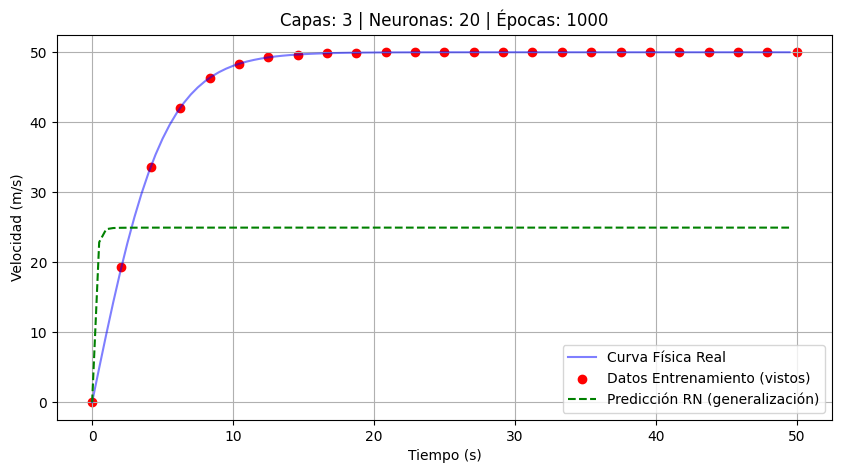

In [62]:
#Grafica RN 20 neuronas 3 capas
plt.figure(figsize=(10, 5))
plt.plot(t_test, v_real, 'b-', label='Curva Física Real', alpha=0.5)
plt.scatter(t_train, v_train, color='red', label='Datos Entrenamiento (vistos)')
plt.plot(t_test, v_pred, 'g--', label='Predicción RN (generalización)')
plt.title(f'Capas: {NUM_CAPAS_OCULTAS} | Neuronas: {NEURONAS_POR_CAPA} | Épocas: {EPOCAS}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()

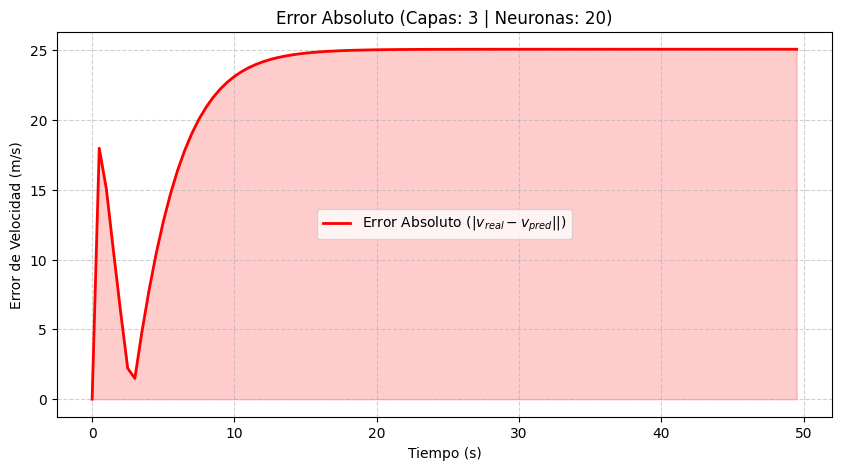

Error Absoluto Medio (MAE): 22.5825 m/s


In [63]:
# 3. Graficar el Error Absoluto
error_absoluto = np.abs(v_real - v_pred)
plt.figure(figsize=(10, 5))
plt.plot(t_test, error_absoluto, color='red', lw=2, label='Error Absoluto ($|v_{real} - v_{pred}|$|)')

# Rellenar el área bajo la curva para mejorar la visualización del acumulado
plt.fill_between(t_test.flatten(), error_absoluto.flatten(), color='red', alpha=0.2)

# Configuración de la gráfica
plt.title('Error Absoluto (Capas: 3 | Neuronas: 20)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Error de Velocidad (m/s)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

# Opcional: Mostrar el error promedio numérico
print(f"Error Absoluto Medio (MAE): {np.mean(error_absoluto):.4f} m/s")

In [64]:
# CONFIGURACIÓN DE LA ARQUITECTURA (Cambia esto)
NUM_CAPAS_OCULTAS = 3       # Cuántas capas quieres entre la entrada y la salida
NEURONAS_POR_CAPA = 40      # Cuántas neuronas tendrá cada una de esas capas
ACTIVACION = 'tanh'         # 'relu', 'tanh' o 'sigmoid'
EPOCAS = 1000               # Cuántas vueltas de entrenamiento dar
# ==========================================


# 3. Construcción Dinámica del Modelo
model = tf.keras.Sequential()

# Capa de entrada
model.add(tf.keras.layers.Input(shape=(1,)))

# Añadimos las capas ocultas según tu configuración
for i in range(NUM_CAPAS_OCULTAS):
    model.add(tf.keras.layers.Dense(NEURONAS_POR_CAPA, activation=ACTIVACION))

# Capa de salida (siempre 1 neurona para predecir la velocidad)
model.add(tf.keras.layers.Dense(1))

model.compile(optimizer='adam', loss='mse')

# 4. Entrenamiento
print(f"Entrenando red con {NUM_CAPAS_OCULTAS} capas de {NEURONAS_POR_CAPA} neuronas...")
history = model.fit(t_train, v_train, epochs=EPOCAS, verbose=0)

# 5. Predicción y Gráfica
v_pred = model.predict(t_test)

Entrenando red con 3 capas de 40 neuronas...
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step


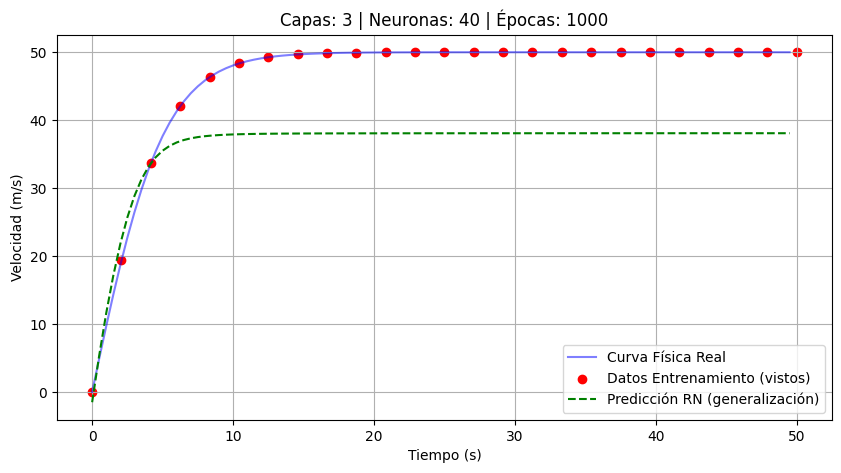

In [65]:
#Grafica RN 40 neuronas 3 capas
plt.figure(figsize=(10, 5))
plt.plot(t_test, v_real, 'b-', label='Curva Física Real', alpha=0.5)
plt.scatter(t_train, v_train, color='red', label='Datos Entrenamiento (vistos)')
plt.plot(t_test, v_pred, 'g--', label='Predicción RN (generalización)')
plt.title(f'Capas: {NUM_CAPAS_OCULTAS} | Neuronas: {NEURONAS_POR_CAPA} | Épocas: {EPOCAS}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()

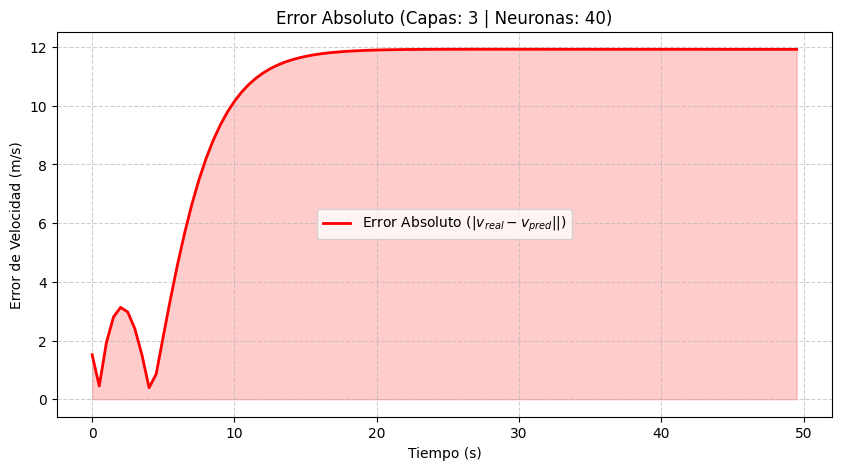

Error Absoluto Medio (MAE): 10.2819 m/s


In [66]:
# 3. Graficar el Error Absoluto
error_absoluto = np.abs(v_real - v_pred)
plt.figure(figsize=(10, 5))
plt.plot(t_test, error_absoluto, color='red', lw=2, label='Error Absoluto ($|v_{real} - v_{pred}|$|)')

# Rellenar el área bajo la curva para mejorar la visualización del acumulado
plt.fill_between(t_test.flatten(), error_absoluto.flatten(), color='red', alpha=0.2)

# Configuración de la gráfica
plt.title('Error Absoluto (Capas: 3 | Neuronas: 40)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Error de Velocidad (m/s)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

# Opcional: Mostrar el error promedio numérico
print(f"Error Absoluto Medio (MAE): {np.mean(error_absoluto):.4f} m/s")

In [67]:
# CONFIGURACIÓN DE LA ARQUITECTURA (Cambia esto)
NUM_CAPAS_OCULTAS = 3       # Cuántas capas quieres entre la entrada y la salida
NEURONAS_POR_CAPA = 60      # Cuántas neuronas tendrá cada una de esas capas
ACTIVACION = 'tanh'         # 'relu', 'tanh' o 'sigmoid'
EPOCAS = 1000               # Cuántas vueltas de entrenamiento dar
# ==========================================


# 3. Construcción Dinámica del Modelo
model = tf.keras.Sequential()

# Capa de entrada
model.add(tf.keras.layers.Input(shape=(1,)))

# Añadimos las capas ocultas según tu configuración
for i in range(NUM_CAPAS_OCULTAS):
    model.add(tf.keras.layers.Dense(NEURONAS_POR_CAPA, activation=ACTIVACION))

# Capa de salida (siempre 1 neurona para predecir la velocidad)
model.add(tf.keras.layers.Dense(1))

model.compile(optimizer='adam', loss='mse')

# 4. Entrenamiento
print(f"Entrenando red con {NUM_CAPAS_OCULTAS} capas de {NEURONAS_POR_CAPA} neuronas...")
history = model.fit(t_train, v_train, epochs=EPOCAS, verbose=0)

# 5. Predicción y Gráfica
v_pred = model.predict(t_test)

Entrenando red con 3 capas de 60 neuronas...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


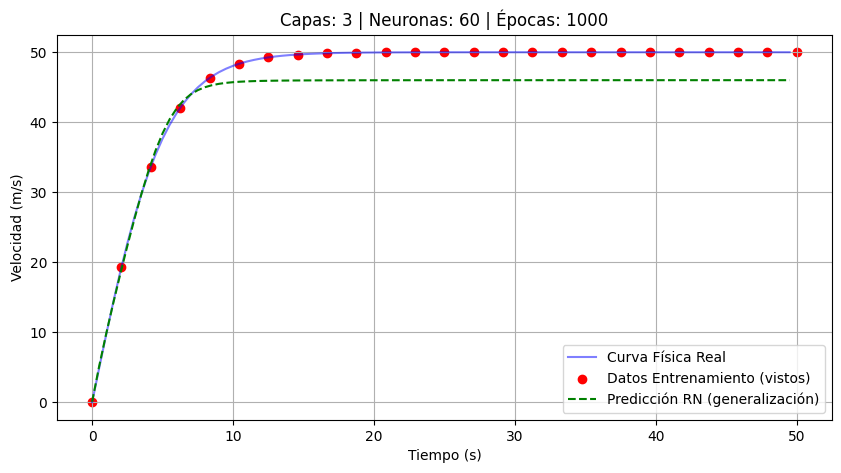

In [68]:
#Grafica RN 60 neuronas 3 capas
plt.figure(figsize=(10, 5))
plt.plot(t_test, v_real, 'b-', label='Curva Física Real', alpha=0.5)
plt.scatter(t_train, v_train, color='red', label='Datos Entrenamiento (vistos)')
plt.plot(t_test, v_pred, 'g--', label='Predicción RN (generalización)')
plt.title(f'Capas: {NUM_CAPAS_OCULTAS} | Neuronas: {NEURONAS_POR_CAPA} | Épocas: {EPOCAS}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()

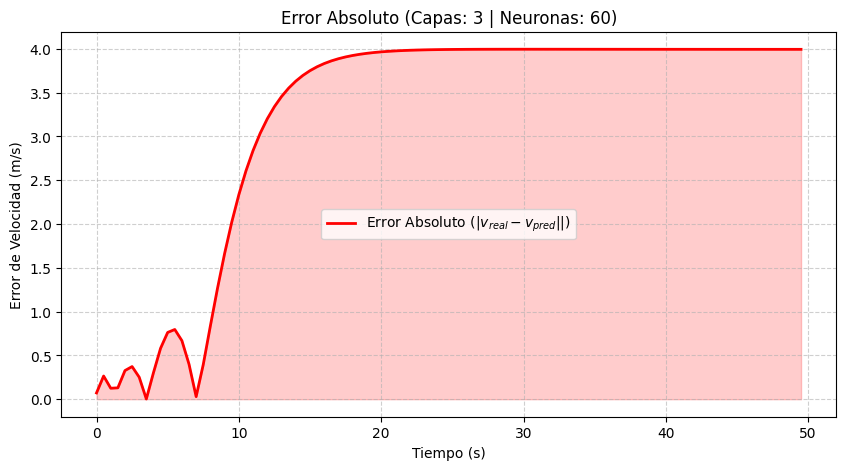

Error Absoluto Medio (MAE): 3.2136 m/s


In [69]:
# 3. Graficar el Error Absoluto
error_absoluto = np.abs(v_real - v_pred)
plt.figure(figsize=(10, 5))
plt.plot(t_test, error_absoluto, color='red', lw=2, label='Error Absoluto ($|v_{real} - v_{pred}|$|)')

# Rellenar el área bajo la curva para mejorar la visualización del acumulado
plt.fill_between(t_test.flatten(), error_absoluto.flatten(), color='red', alpha=0.2)

# Configuración de la gráfica
plt.title('Error Absoluto (Capas: 3 | Neuronas: 60)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Error de Velocidad (m/s)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

# Opcional: Mostrar el error promedio numérico
print(f"Error Absoluto Medio (MAE): {np.mean(error_absoluto):.4f} m/s")

In [70]:
# CONFIGURACIÓN DE LA ARQUITECTURA (Cambia esto)
NUM_CAPAS_OCULTAS = 3       # Cuántas capas quieres entre la entrada y la salida
NEURONAS_POR_CAPA = 80      # Cuántas neuronas tendrá cada una de esas capas
ACTIVACION = 'tanh'         # 'relu', 'tanh' o 'sigmoid'
EPOCAS = 1000               # Cuántas vueltas de entrenamiento dar
# ==========================================


# 3. Construcción Dinámica del Modelo
model = tf.keras.Sequential()

# Capa de entrada
model.add(tf.keras.layers.Input(shape=(1,)))

# Añadimos las capas ocultas según tu configuración
for i in range(NUM_CAPAS_OCULTAS):
    model.add(tf.keras.layers.Dense(NEURONAS_POR_CAPA, activation=ACTIVACION))

# Capa de salida (siempre 1 neurona para predecir la velocidad)
model.add(tf.keras.layers.Dense(1))

model.compile(optimizer='adam', loss='mse')

# 4. Entrenamiento
print(f"Entrenando red con {NUM_CAPAS_OCULTAS} capas de {NEURONAS_POR_CAPA} neuronas...")
history = model.fit(t_train, v_train, epochs=EPOCAS, verbose=0)

# 5. Predicción y Gráfica
v_pred = model.predict(t_test)

Entrenando red con 3 capas de 80 neuronas...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


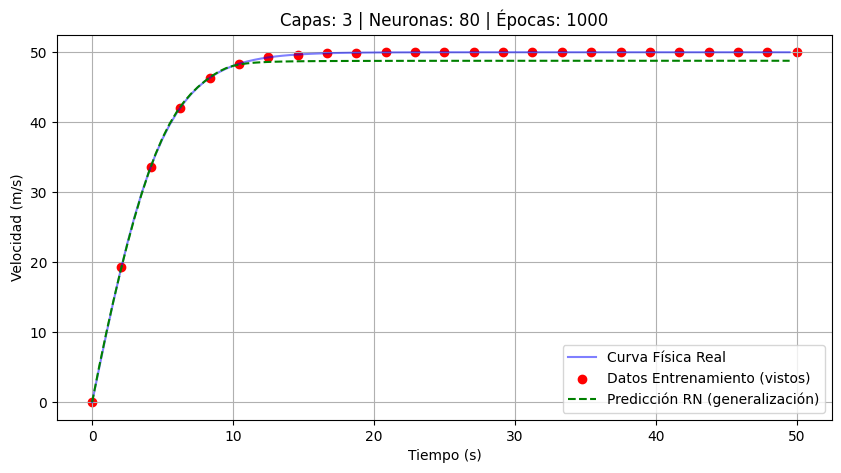

In [71]:
#Grafica RN 80 neuronas 3 capas
plt.figure(figsize=(10, 5))
plt.plot(t_test, v_real, 'b-', label='Curva Física Real', alpha=0.5)
plt.scatter(t_train, v_train, color='red', label='Datos Entrenamiento (vistos)')
plt.plot(t_test, v_pred, 'g--', label='Predicción RN (generalización)')
plt.title(f'Capas: {NUM_CAPAS_OCULTAS} | Neuronas: {NEURONAS_POR_CAPA} | Épocas: {EPOCAS}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()

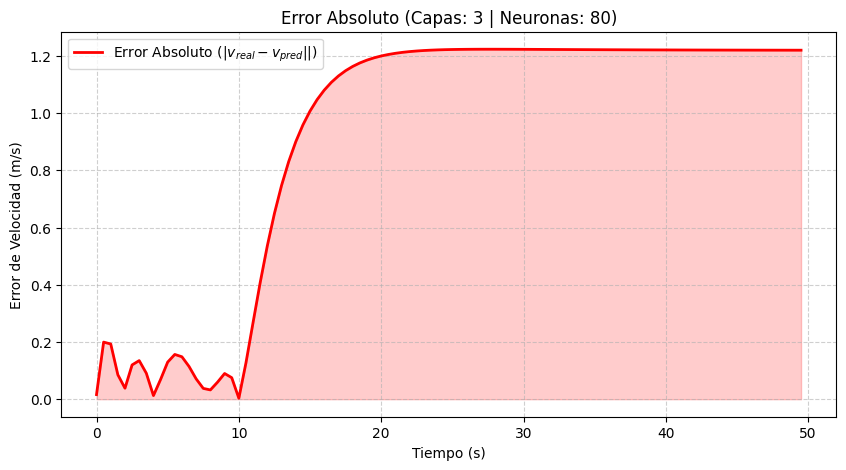

Error Absoluto Medio (MAE): 0.9177 m/s


In [72]:
# 3. Graficar el Error Absoluto
error_absoluto = np.abs(v_real - v_pred)
plt.figure(figsize=(10, 5))
plt.plot(t_test, error_absoluto, color='red', lw=2, label='Error Absoluto ($|v_{real} - v_{pred}|$|)')

# Rellenar el área bajo la curva para mejorar la visualización del acumulado
plt.fill_between(t_test.flatten(), error_absoluto.flatten(), color='red', alpha=0.2)

# Configuración de la gráfica
plt.title('Error Absoluto (Capas: 3 | Neuronas: 80)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Error de Velocidad (m/s)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

# Opcional: Mostrar el error promedio numérico
print(f"Error Absoluto Medio (MAE): {np.mean(error_absoluto):.4f} m/s")

In [73]:
# CONFIGURACIÓN DE LA ARQUITECTURA (Cambia esto)
NUM_CAPAS_OCULTAS = 3       # Cuántas capas quieres entre la entrada y la salida
NEURONAS_POR_CAPA = 100      # Cuántas neuronas tendrá cada una de esas capas
ACTIVACION = 'tanh'         # 'relu', 'tanh' o 'sigmoid'
EPOCAS = 1000               # Cuántas vueltas de entrenamiento dar
# ==========================================


# 3. Construcción Dinámica del Modelo
model = tf.keras.Sequential()

# Capa de entrada
model.add(tf.keras.layers.Input(shape=(1,)))

# Añadimos las capas ocultas según tu configuración
for i in range(NUM_CAPAS_OCULTAS):
    model.add(tf.keras.layers.Dense(NEURONAS_POR_CAPA, activation=ACTIVACION))

# Capa de salida (siempre 1 neurona para predecir la velocidad)
model.add(tf.keras.layers.Dense(1))

model.compile(optimizer='adam', loss='mse')

# 4. Entrenamiento
print(f"Entrenando red con {NUM_CAPAS_OCULTAS} capas de {NEURONAS_POR_CAPA} neuronas...")
history = model.fit(t_train, v_train, epochs=EPOCAS, verbose=0)

# 5. Predicción y Gráfica
v_pred = model.predict(t_test)

Entrenando red con 3 capas de 100 neuronas...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


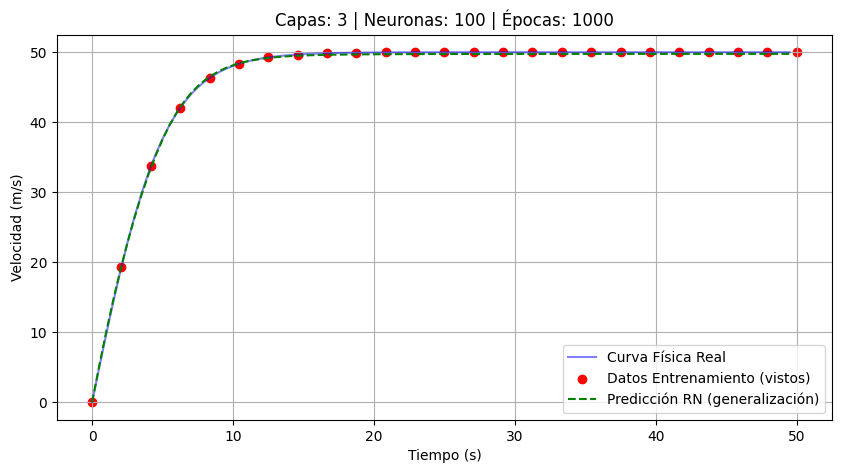

In [74]:
#Grafica RN 80 neuronas 3 capas
plt.figure(figsize=(10, 5))
plt.plot(t_test, v_real, 'b-', label='Curva Física Real', alpha=0.5)
plt.scatter(t_train, v_train, color='red', label='Datos Entrenamiento (vistos)')
plt.plot(t_test, v_pred, 'g--', label='Predicción RN (generalización)')
plt.title(f'Capas: {NUM_CAPAS_OCULTAS} | Neuronas: {NEURONAS_POR_CAPA} | Épocas: {EPOCAS}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()

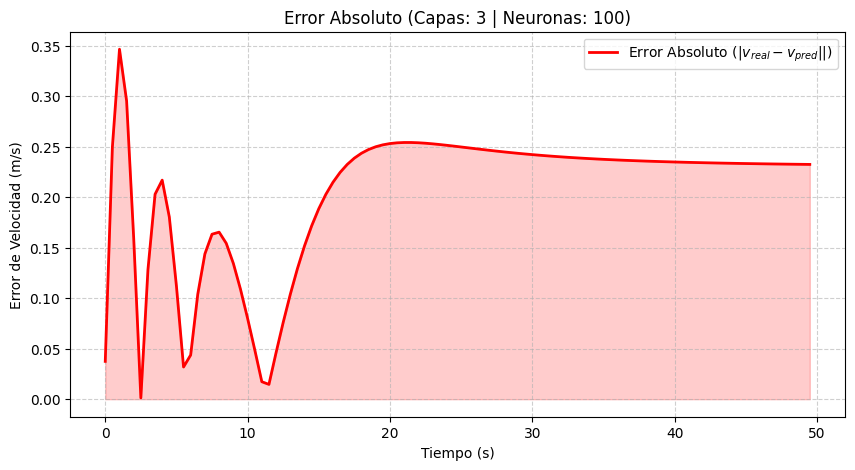

Error Absoluto Medio (MAE): 0.2054 m/s


In [75]:
# 3. Graficar el Error Absoluto
error_absoluto = np.abs(v_real - v_pred)
plt.figure(figsize=(10, 5))
plt.plot(t_test, error_absoluto, color='red', lw=2, label='Error Absoluto ($|v_{real} - v_{pred}|$|)')

# Rellenar el área bajo la curva para mejorar la visualización del acumulado
plt.fill_between(t_test.flatten(), error_absoluto.flatten(), color='red', alpha=0.2)

# Configuración de la gráfica
plt.title('Error Absoluto (Capas: 3 | Neuronas: 100)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Error de Velocidad (m/s)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

# Opcional: Mostrar el error promedio numérico
print(f"Error Absoluto Medio (MAE): {np.mean(error_absoluto):.4f} m/s")

# Capas: XX, Activacion 'tanh', Neuronas: 100

In [76]:
# CONFIGURACIÓN DE LA ARQUITECTURA (Cambia esto)
NUM_CAPAS_OCULTAS = 6       # Cuántas capas quieres entre la entrada y la salida
NEURONAS_POR_CAPA = 100      # Cuántas neuronas tendrá cada una de esas capas
ACTIVACION = 'tanh'         # 'relu', 'tanh' o 'sigmoid'
EPOCAS = 1000               # Cuántas vueltas de entrenamiento dar
# ==========================================


# 3. Construcción Dinámica del Modelo
model = tf.keras.Sequential()

# Capa de entrada
model.add(tf.keras.layers.Input(shape=(1,)))

# Añadimos las capas ocultas según tu configuración
for i in range(NUM_CAPAS_OCULTAS):
    model.add(tf.keras.layers.Dense(NEURONAS_POR_CAPA, activation=ACTIVACION))

# Capa de salida (siempre 1 neurona para predecir la velocidad)
model.add(tf.keras.layers.Dense(1))

model.compile(optimizer='adam', loss='mse')

# 4. Entrenamiento
print(f"Entrenando red con {NUM_CAPAS_OCULTAS} capas de {NEURONAS_POR_CAPA} neuronas...")
history = model.fit(t_train, v_train, epochs=EPOCAS, verbose=0)

# 5. Predicción y Gráfica
v_pred = model.predict(t_test)

Entrenando red con 6 capas de 100 neuronas...
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step


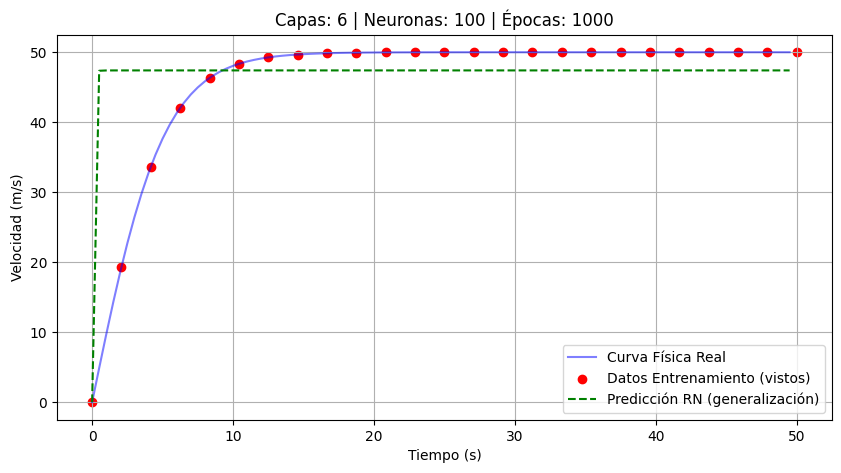

In [77]:
#Grafica RN 60 neuronas 6 capas
plt.figure(figsize=(10, 5))
plt.plot(t_test, v_real, 'b-', label='Curva Física Real', alpha=0.5)
plt.scatter(t_train, v_train, color='red', label='Datos Entrenamiento (vistos)')
plt.plot(t_test, v_pred, 'g--', label='Predicción RN (generalización)')
plt.title(f'Capas: {NUM_CAPAS_OCULTAS} | Neuronas: {NEURONAS_POR_CAPA} | Épocas: {EPOCAS}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()

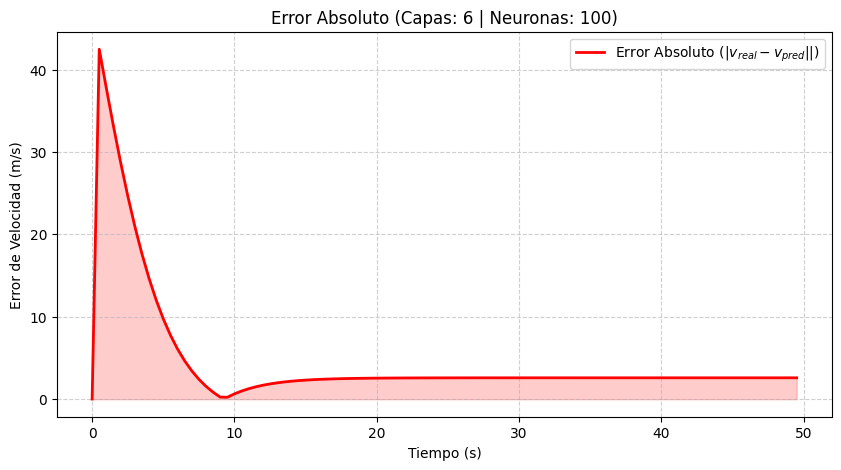

Error Absoluto Medio (MAE): 4.6593 m/s


In [78]:
# 3. Graficar el Error Absoluto
error_absoluto = np.abs(v_real - v_pred)
plt.figure(figsize=(10, 5))
plt.plot(t_test, error_absoluto, color='red', lw=2, label='Error Absoluto ($|v_{real} - v_{pred}|$|)')

# Rellenar el área bajo la curva para mejorar la visualización del acumulado
plt.fill_between(t_test.flatten(), error_absoluto.flatten(), color='red', alpha=0.2)

# Configuración de la gráfica
plt.title('Error Absoluto (Capas: 6 | Neuronas: 100)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Error de Velocidad (m/s)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

# Opcional: Mostrar el error promedio numérico
print(f"Error Absoluto Medio (MAE): {np.mean(error_absoluto):.4f} m/s")

In [79]:
# CONFIGURACIÓN DE LA ARQUITECTURA (Cambia esto)
NUM_CAPAS_OCULTAS = 9       # Cuántas capas quieres entre la entrada y la salida
NEURONAS_POR_CAPA = 100      # Cuántas neuronas tendrá cada una de esas capas
ACTIVACION = 'tanh'         # 'relu', 'tanh' o 'sigmoid'
EPOCAS = 1000               # Cuántas vueltas de entrenamiento dar
# ==========================================


# 3. Construcción Dinámica del Modelo
model = tf.keras.Sequential()

# Capa de entrada
model.add(tf.keras.layers.Input(shape=(1,)))

# Añadimos las capas ocultas según tu configuración
for i in range(NUM_CAPAS_OCULTAS):
    model.add(tf.keras.layers.Dense(NEURONAS_POR_CAPA, activation=ACTIVACION))

# Capa de salida (siempre 1 neurona para predecir la velocidad)
model.add(tf.keras.layers.Dense(1))

model.compile(optimizer='adam', loss='mse')

# 4. Entrenamiento
print(f"Entrenando red con {NUM_CAPAS_OCULTAS} capas de {NEURONAS_POR_CAPA} neuronas...")
history = model.fit(t_train, v_train, epochs=EPOCAS, verbose=0)

# 5. Predicción y Gráfica
v_pred = model.predict(t_test)

Entrenando red con 9 capas de 100 neuronas...
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step


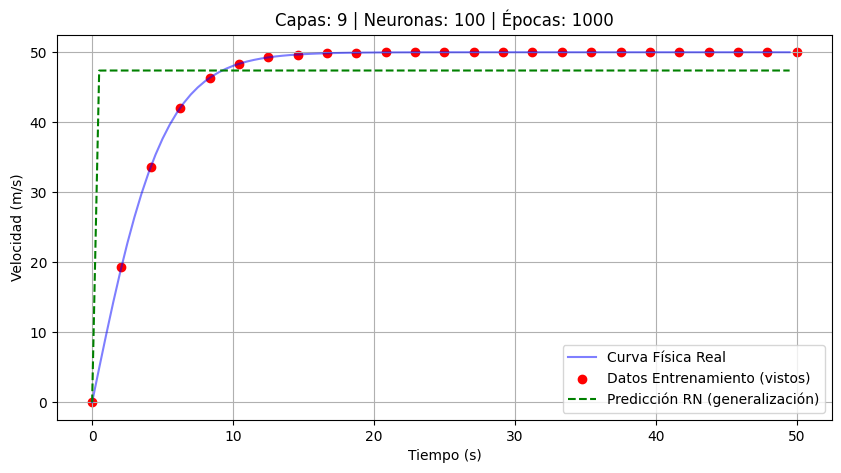

In [80]:
#Grafica RN 60 neuronas 9 capas
plt.figure(figsize=(10, 5))
plt.plot(t_test, v_real, 'b-', label='Curva Física Real', alpha=0.5)
plt.scatter(t_train, v_train, color='red', label='Datos Entrenamiento (vistos)')
plt.plot(t_test, v_pred, 'g--', label='Predicción RN (generalización)')
plt.title(f'Capas: {NUM_CAPAS_OCULTAS} | Neuronas: {NEURONAS_POR_CAPA} | Épocas: {EPOCAS}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()

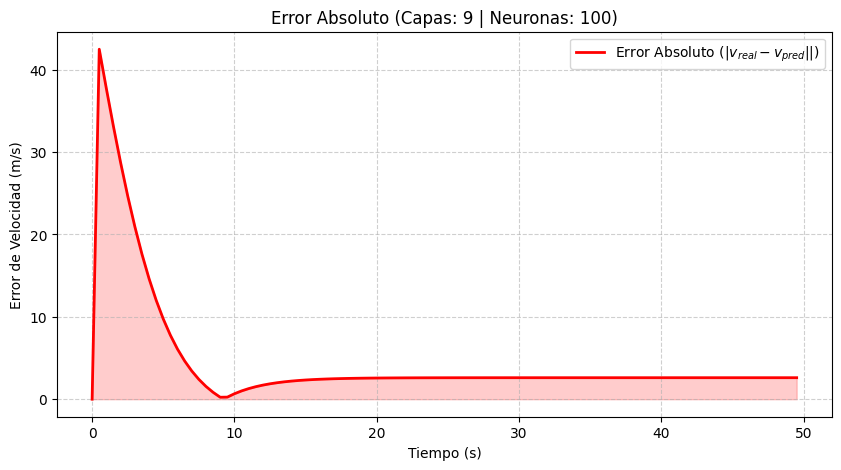

Error Absoluto Medio (MAE): 4.6689 m/s


In [81]:
# 3. Graficar el Error Absoluto
error_absoluto = np.abs(v_real - v_pred)
plt.figure(figsize=(10, 5))
plt.plot(t_test, error_absoluto, color='red', lw=2, label='Error Absoluto ($|v_{real} - v_{pred}|$|)')

# Rellenar el área bajo la curva para mejorar la visualización del acumulado
plt.fill_between(t_test.flatten(), error_absoluto.flatten(), color='red', alpha=0.2)

# Configuración de la gráfica
plt.title('Error Absoluto (Capas: 9 | Neuronas: 100)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Error de Velocidad (m/s)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

# Opcional: Mostrar el error promedio numérico
print(f"Error Absoluto Medio (MAE): {np.mean(error_absoluto):.4f} m/s")

In [82]:
# CONFIGURACIÓN DE LA ARQUITECTURA (Cambia esto)
NUM_CAPAS_OCULTAS = 2       # Cuántas capas quieres entre la entrada y la salida
NEURONAS_POR_CAPA = 100      # Cuántas neuronas tendrá cada una de esas capas
ACTIVACION = 'tanh'         # 'relu', 'tanh' o 'sigmoid'
EPOCAS = 1000               # Cuántas vueltas de entrenamiento dar
# ==========================================


# 3. Construcción Dinámica del Modelo
model = tf.keras.Sequential()

# Capa de entrada
model.add(tf.keras.layers.Input(shape=(1,)))

# Añadimos las capas ocultas según tu configuración
for i in range(NUM_CAPAS_OCULTAS):
    model.add(tf.keras.layers.Dense(NEURONAS_POR_CAPA, activation=ACTIVACION))

# Capa de salida (siempre 1 neurona para predecir la velocidad)
model.add(tf.keras.layers.Dense(1))

model.compile(optimizer='adam', loss='mse')

# 4. Entrenamiento
print(f"Entrenando red con {NUM_CAPAS_OCULTAS} capas de {NEURONAS_POR_CAPA} neuronas...")
history = model.fit(t_train, v_train, epochs=EPOCAS, verbose=0)

# 5. Predicción y Gráfica
v_pred = model.predict(t_test)

Entrenando red con 2 capas de 100 neuronas...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


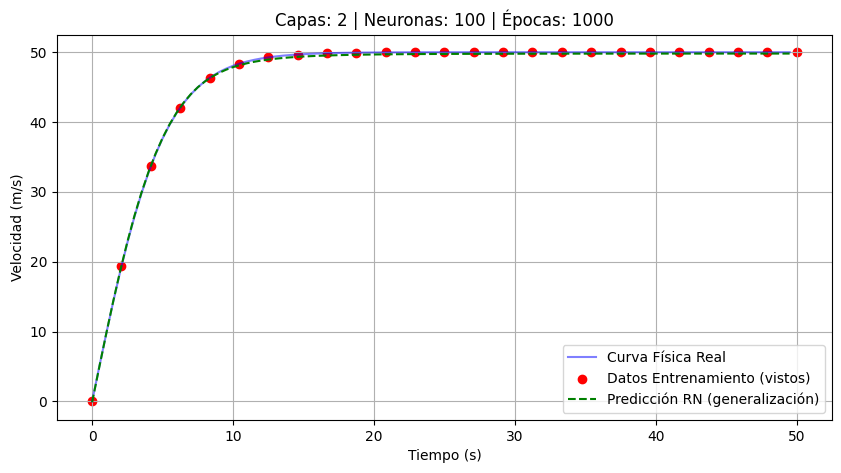

In [83]:
#Grafica RN 60 neuronas 2 capas
plt.figure(figsize=(10, 5))
plt.plot(t_test, v_real, 'b-', label='Curva Física Real', alpha=0.5)
plt.scatter(t_train, v_train, color='red', label='Datos Entrenamiento (vistos)')
plt.plot(t_test, v_pred, 'g--', label='Predicción RN (generalización)')
plt.title(f'Capas: {NUM_CAPAS_OCULTAS} | Neuronas: {NEURONAS_POR_CAPA} | Épocas: {EPOCAS}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()

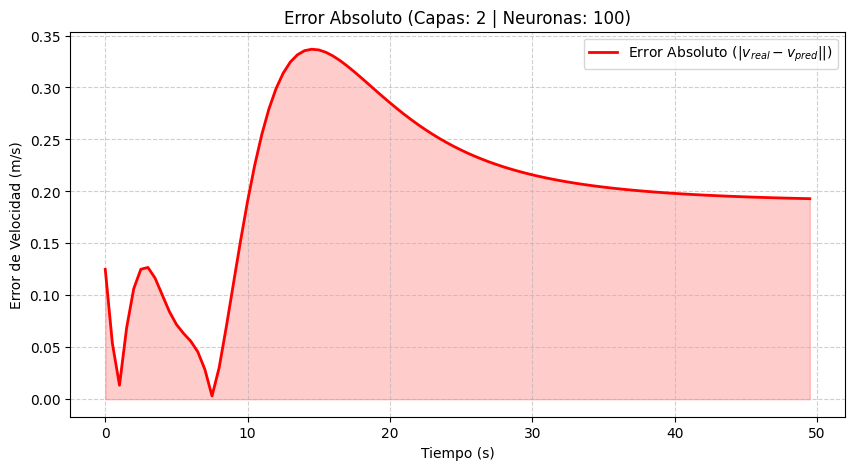

Error Absoluto Medio (MAE): 0.2052 m/s


In [84]:
# 3. Graficar el Error Absoluto
error_absoluto = np.abs(v_real - v_pred)
plt.figure(figsize=(10, 5))
plt.plot(t_test, error_absoluto, color='red', lw=2, label='Error Absoluto ($|v_{real} - v_{pred}|$|)')

# Rellenar el área bajo la curva para mejorar la visualización del acumulado
plt.fill_between(t_test.flatten(), error_absoluto.flatten(), color='red', alpha=0.2)

# Configuración de la gráfica
plt.title('Error Absoluto (Capas: 2 | Neuronas: 100)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Error de Velocidad (m/s)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

# Opcional: Mostrar el error promedio numérico
print(f"Error Absoluto Medio (MAE): {np.mean(error_absoluto):.4f} m/s")

In [85]:
# CONFIGURACIÓN DE LA ARQUITECTURA (Cambia esto)
NUM_CAPAS_OCULTAS = 1       # Cuántas capas quieres entre la entrada y la salida
NEURONAS_POR_CAPA = 100      # Cuántas neuronas tendrá cada una de esas capas
ACTIVACION = 'tanh'         # 'relu', 'tanh' o 'sigmoid'
EPOCAS = 1000               # Cuántas vueltas de entrenamiento dar
# ==========================================


# 3. Construcción Dinámica del Modelo
model = tf.keras.Sequential()

# Capa de entrada
model.add(tf.keras.layers.Input(shape=(1,)))

# Añadimos las capas ocultas según tu configuración
for i in range(NUM_CAPAS_OCULTAS):
    model.add(tf.keras.layers.Dense(NEURONAS_POR_CAPA, activation=ACTIVACION))

# Capa de salida (siempre 1 neurona para predecir la velocidad)
model.add(tf.keras.layers.Dense(1))

model.compile(optimizer='adam', loss='mse')

# 4. Entrenamiento
print(f"Entrenando red con {NUM_CAPAS_OCULTAS} capas de {NEURONAS_POR_CAPA} neuronas...")
history = model.fit(t_train, v_train, epochs=EPOCAS, verbose=0)

# 5. Predicción y Gráfica
v_pred = model.predict(t_test)

Entrenando red con 1 capas de 100 neuronas...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


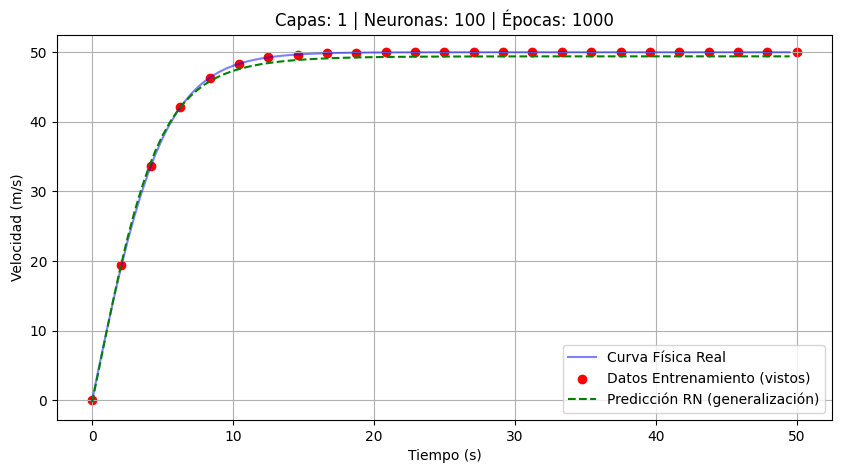

In [86]:
#Grafica RN 100 neuronas 1 capas
plt.figure(figsize=(10, 5))
plt.plot(t_test, v_real, 'b-', label='Curva Física Real', alpha=0.5)
plt.scatter(t_train, v_train, color='red', label='Datos Entrenamiento (vistos)')
plt.plot(t_test, v_pred, 'g--', label='Predicción RN (generalización)')
plt.title(f'Capas: {NUM_CAPAS_OCULTAS} | Neuronas: {NEURONAS_POR_CAPA} | Épocas: {EPOCAS}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()

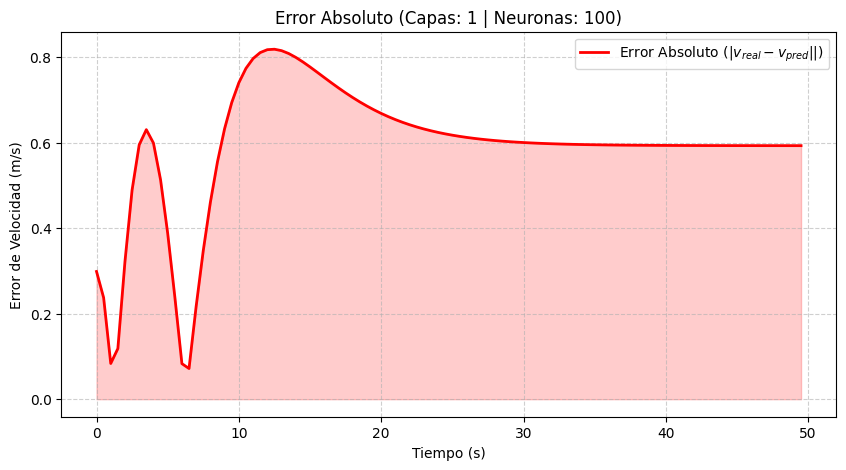

Error Absoluto Medio (MAE): 0.5906 m/s


In [87]:
# 3. Graficar el Error Absoluto
error_absoluto = np.abs(v_real - v_pred)
plt.figure(figsize=(10, 5))
plt.plot(t_test, error_absoluto, color='red', lw=2, label='Error Absoluto ($|v_{real} - v_{pred}|$|)')

# Rellenar el área bajo la curva para mejorar la visualización del acumulado
plt.fill_between(t_test.flatten(), error_absoluto.flatten(), color='red', alpha=0.2)

# Configuración de la gráfica
plt.title('Error Absoluto (Capas: 1 | Neuronas: 100)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Error de Velocidad (m/s)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

# Opcional: Mostrar el error promedio numérico
print(f"Error Absoluto Medio (MAE): {np.mean(error_absoluto):.4f} m/s")

# Capas: 2, Activacion 'XXXXX', Neuronas: 100

In [88]:
# CONFIGURACIÓN DE LA ARQUITECTURA (Cambia esto)
NUM_CAPAS_OCULTAS = 2       # Cuántas capas quieres entre la entrada y la salida
NEURONAS_POR_CAPA = 100      # Cuántas neuronas tendrá cada una de esas capas
ACTIVACION = 'relu'         # 'relu', 'tanh' o 'sigmoid'
EPOCAS = 1000               # Cuántas vueltas de entrenamiento dar
# ==========================================


# 3. Construcción Dinámica del Modelo
model = tf.keras.Sequential()

# Capa de entrada
model.add(tf.keras.layers.Input(shape=(1,)))

# Añadimos las capas ocultas según tu configuración
for i in range(NUM_CAPAS_OCULTAS):
    model.add(tf.keras.layers.Dense(NEURONAS_POR_CAPA, activation=ACTIVACION))

# Capa de salida (siempre 1 neurona para predecir la velocidad)
model.add(tf.keras.layers.Dense(1))

model.compile(optimizer='adam', loss='mse')

# 4. Entrenamiento
print(f"Entrenando red con {NUM_CAPAS_OCULTAS} capas de {NEURONAS_POR_CAPA} neuronas...")
history = model.fit(t_train, v_train, epochs=EPOCAS, verbose=0)

# 5. Predicción y Gráfica
v_pred = model.predict(t_test)

Entrenando red con 2 capas de 100 neuronas...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


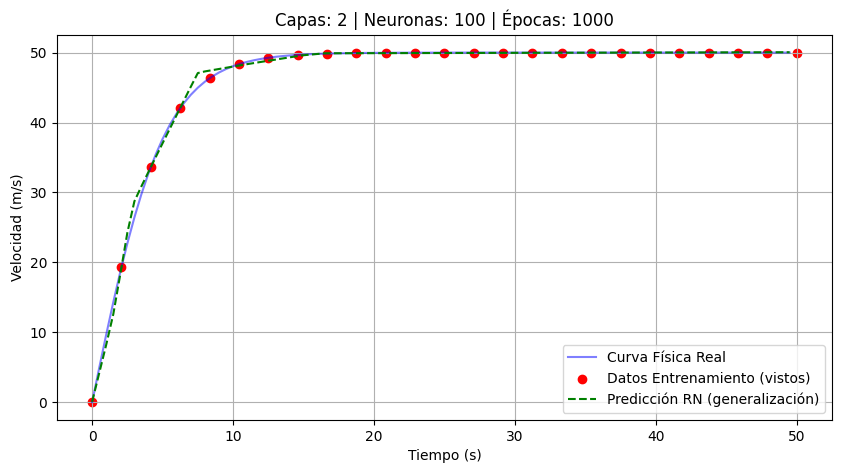

In [89]:
#Grafica RN 100 neuronas 2 capas
plt.figure(figsize=(10, 5))
plt.plot(t_test, v_real, 'b-', label='Curva Física Real', alpha=0.5)
plt.scatter(t_train, v_train, color='red', label='Datos Entrenamiento (vistos)')
plt.plot(t_test, v_pred, 'g--', label='Predicción RN (generalización)')
plt.title(f'Capas: {NUM_CAPAS_OCULTAS} | Neuronas: {NEURONAS_POR_CAPA} | Épocas: {EPOCAS}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()

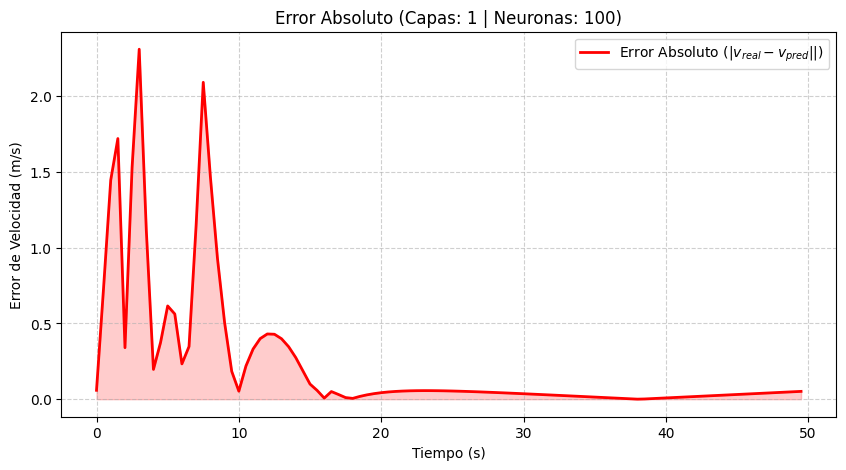

Error Absoluto Medio (MAE): 0.2327 m/s


In [90]:
# 3. Graficar el Error Absoluto
error_absoluto = np.abs(v_real - v_pred)
plt.figure(figsize=(10, 5))
plt.plot(t_test, error_absoluto, color='red', lw=2, label='Error Absoluto ($|v_{real} - v_{pred}|$|)')

# Rellenar el área bajo la curva para mejorar la visualización del acumulado
plt.fill_between(t_test.flatten(), error_absoluto.flatten(), color='red', alpha=0.2)

# Configuración de la gráfica
plt.title('Error Absoluto (Capas: 2 | Neuronas: 100)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Error de Velocidad (m/s)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

# Opcional: Mostrar el error promedio numérico
print(f"Error Absoluto Medio (MAE): {np.mean(error_absoluto):.4f} m/s")

In [91]:
# CONFIGURACIÓN DE LA ARQUITECTURA (Cambia esto)
NUM_CAPAS_OCULTAS = 2       # Cuántas capas quieres entre la entrada y la salida
NEURONAS_POR_CAPA = 100      # Cuántas neuronas tendrá cada una de esas capas
ACTIVACION = 'sigmoid'         # 'relu', 'tanh' o 'sigmoid'
EPOCAS = 1000               # Cuántas vueltas de entrenamiento dar
# ==========================================


# 3. Construcción Dinámica del Modelo
model = tf.keras.Sequential()

# Capa de entrada
model.add(tf.keras.layers.Input(shape=(1,)))

# Añadimos las capas ocultas según tu configuración
for i in range(NUM_CAPAS_OCULTAS):
    model.add(tf.keras.layers.Dense(NEURONAS_POR_CAPA, activation=ACTIVACION))

# Capa de salida (siempre 1 neurona para predecir la velocidad)
model.add(tf.keras.layers.Dense(1))

model.compile(optimizer='adam', loss='mse')

# 4. Entrenamiento
print(f"Entrenando red con {NUM_CAPAS_OCULTAS} capas de {NEURONAS_POR_CAPA} neuronas...")
history = model.fit(t_train, v_train, epochs=EPOCAS, verbose=0)

# 5. Predicción y Gráfica
v_pred = model.predict(t_test)

Entrenando red con 2 capas de 100 neuronas...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


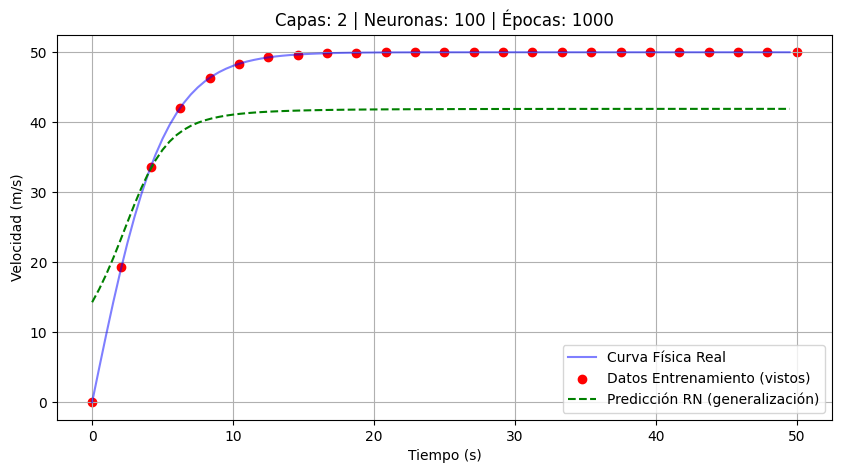

In [92]:
#Grafica RN 100 neuronas 2 capas
plt.figure(figsize=(10, 5))
plt.plot(t_test, v_real, 'b-', label='Curva Física Real', alpha=0.5)
plt.scatter(t_train, v_train, color='red', label='Datos Entrenamiento (vistos)')
plt.plot(t_test, v_pred, 'g--', label='Predicción RN (generalización)')
plt.title(f'Capas: {NUM_CAPAS_OCULTAS} | Neuronas: {NEURONAS_POR_CAPA} | Épocas: {EPOCAS}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()

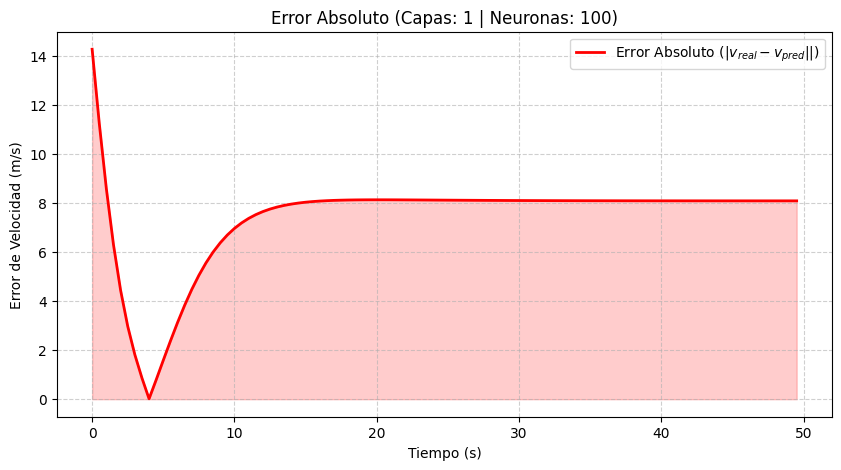

Error Absoluto Medio (MAE): 7.3997 m/s


In [93]:
# 3. Graficar el Error Absoluto
error_absoluto = np.abs(v_real - v_pred)
plt.figure(figsize=(10, 5))
plt.plot(t_test, error_absoluto, color='red', lw=2, label='Error Absoluto ($|v_{real} - v_{pred}|$|)')

# Rellenar el área bajo la curva para mejorar la visualización del acumulado
plt.fill_between(t_test.flatten(), error_absoluto.flatten(), color='red', alpha=0.2)

# Configuración de la gráfica
plt.title('Error Absoluto (Capas: 1 | Neuronas: 100)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Error de Velocidad (m/s)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

# Opcional: Mostrar el error promedio numérico
print(f"Error Absoluto Medio (MAE): {np.mean(error_absoluto):.4f} m/s")

In [94]:
# CONFIGURACIÓN DE LA ARQUITECTURA (Cambia esto)
NUM_CAPAS_OCULTAS = 2       # Cuántas capas quieres entre la entrada y la salida
NEURONAS_POR_CAPA = 100      # Cuántas neuronas tendrá cada una de esas capas
ACTIVACION = 'elu'         # 'relu', 'tanh' o 'sigmoid'
EPOCAS = 1000               # Cuántas vueltas de entrenamiento dar
# ==========================================


# 3. Construcción Dinámica del Modelo
model = tf.keras.Sequential()

# Capa de entrada
model.add(tf.keras.layers.Input(shape=(1,)))

# Añadimos las capas ocultas según tu configuración
for i in range(NUM_CAPAS_OCULTAS):
    model.add(tf.keras.layers.Dense(NEURONAS_POR_CAPA, activation=ACTIVACION))

# Capa de salida (siempre 1 neurona para predecir la velocidad)
model.add(tf.keras.layers.Dense(1))

model.compile(optimizer='adam', loss='mse')

# 4. Entrenamiento
print(f"Entrenando red con {NUM_CAPAS_OCULTAS} capas de {NEURONAS_POR_CAPA} neuronas...")
history = model.fit(t_train, v_train, epochs=EPOCAS, verbose=0)

# 5. Predicción y Gráfica
v_pred = model.predict(t_test)

Entrenando red con 2 capas de 100 neuronas...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


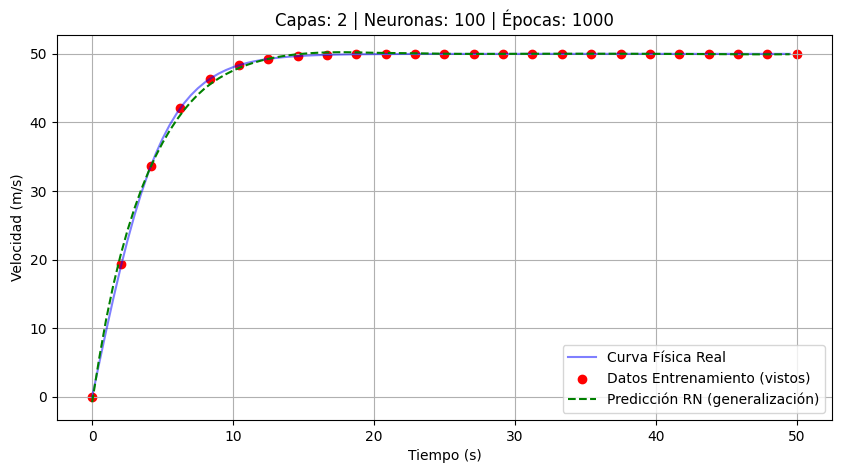

In [95]:
#Grafica RN 100 neuronas 2 capas
plt.figure(figsize=(10, 5))
plt.plot(t_test, v_real, 'b-', label='Curva Física Real', alpha=0.5)
plt.scatter(t_train, v_train, color='red', label='Datos Entrenamiento (vistos)')
plt.plot(t_test, v_pred, 'g--', label='Predicción RN (generalización)')
plt.title(f'Capas: {NUM_CAPAS_OCULTAS} | Neuronas: {NEURONAS_POR_CAPA} | Épocas: {EPOCAS}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()

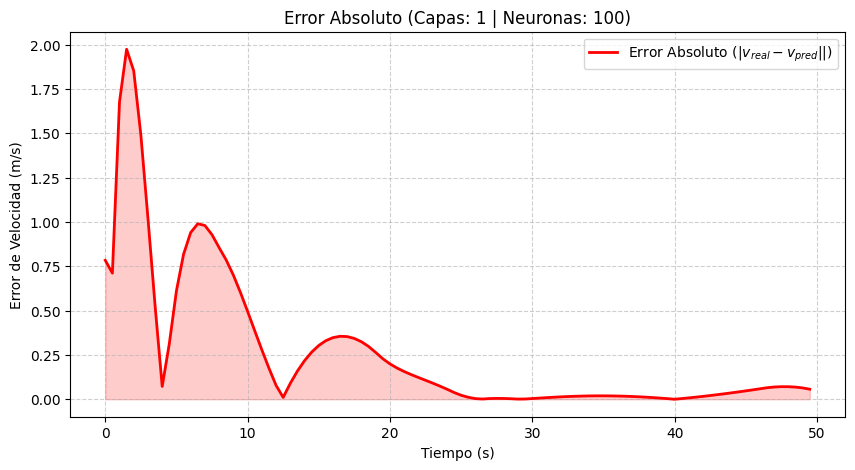

Error Absoluto Medio (MAE): 0.2624 m/s


In [96]:
# 3. Graficar el Error Absoluto
error_absoluto = np.abs(v_real - v_pred)
plt.figure(figsize=(10, 5))
plt.plot(t_test, error_absoluto, color='red', lw=2, label='Error Absoluto ($|v_{real} - v_{pred}|$|)')

# Rellenar el área bajo la curva para mejorar la visualización del acumulado
plt.fill_between(t_test.flatten(), error_absoluto.flatten(), color='red', alpha=0.2)

# Configuración de la gráfica
plt.title('Error Absoluto (Capas: 1 | Neuronas: 100)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Error de Velocidad (m/s)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

# Opcional: Mostrar el error promedio numérico
print(f"Error Absoluto Medio (MAE): {np.mean(error_absoluto):.4f} m/s")

# Mejor configuracion Capas: 2, Neuronas: 500, Activacion 'tanh'

In [100]:
# CONFIGURACIÓN DE LA ARQUITECTURA (Cambia esto)
NUM_CAPAS_OCULTAS = 2       # Cuántas capas quieres entre la entrada y la salida
NEURONAS_POR_CAPA = 500      # Cuántas neuronas tendrá cada una de esas capas
ACTIVACION = 'tanh'         # 'relu', 'tanh' o 'sigmoid'
EPOCAS = 1000               # Cuántas vueltas de entrenamiento dar
# ==========================================


# 3. Construcción Dinámica del Modelo
model = tf.keras.Sequential()

# Capa de entrada
model.add(tf.keras.layers.Input(shape=(1,)))

# Añadimos las capas ocultas según tu configuración
for i in range(NUM_CAPAS_OCULTAS):
    model.add(tf.keras.layers.Dense(NEURONAS_POR_CAPA, activation=ACTIVACION))

# Capa de salida (siempre 1 neurona para predecir la velocidad)
model.add(tf.keras.layers.Dense(1))

model.compile(optimizer='adam', loss='mse')

# 4. Entrenamiento
print(f"Entrenando red con {NUM_CAPAS_OCULTAS} capas de {NEURONAS_POR_CAPA} neuronas...")
history = model.fit(t_train, v_train, epochs=EPOCAS, verbose=0)

# 5. Predicción y Gráfica
v_pred = model.predict(t_test)

Entrenando red con 2 capas de 500 neuronas...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


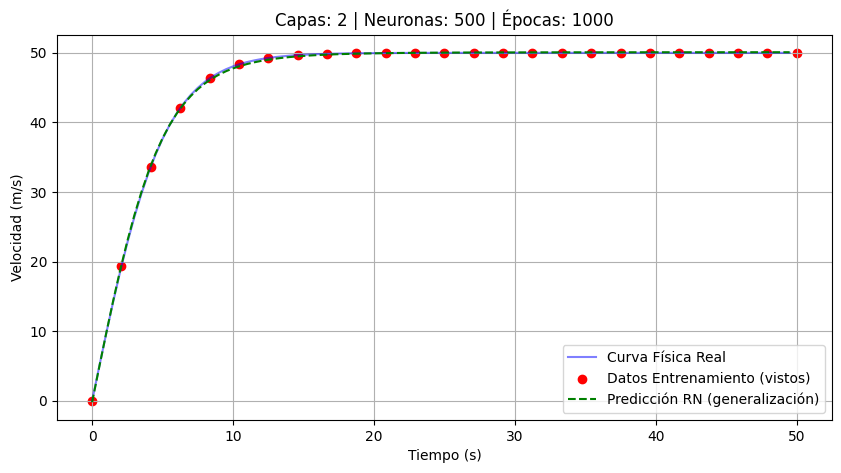

In [101]:
#Grafica RN 250 neuronas 2 capas
plt.figure(figsize=(10, 5))
plt.plot(t_test, v_real, 'b-', label='Curva Física Real', alpha=0.5)
plt.scatter(t_train, v_train, color='red', label='Datos Entrenamiento (vistos)')
plt.plot(t_test, v_pred, 'g--', label='Predicción RN (generalización)')
plt.title(f'Capas: {NUM_CAPAS_OCULTAS} | Neuronas: {NEURONAS_POR_CAPA} | Épocas: {EPOCAS}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()

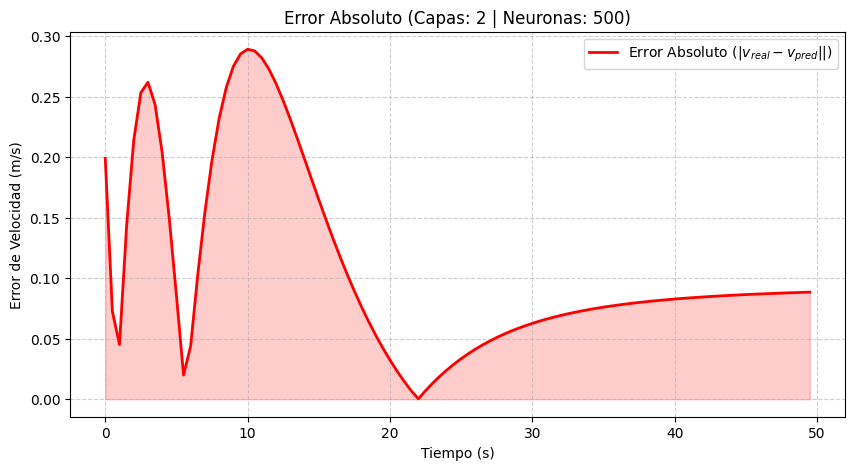

Error Absoluto Medio (MAE): 0.1076 m/s


In [103]:
# 3. Graficar el Error Absoluto
error_absoluto = np.abs(v_real - v_pred)
plt.figure(figsize=(10, 5))
plt.plot(t_test, error_absoluto, color='red', lw=2, label='Error Absoluto ($|v_{real} - v_{pred}|$|)')

# Rellenar el área bajo la curva para mejorar la visualización del acumulado
plt.fill_between(t_test.flatten(), error_absoluto.flatten(), color='red', alpha=0.2)

# Configuración de la gráfica
plt.title('Error Absoluto (Capas: 2 | Neuronas: 500)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Error de Velocidad (m/s)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

# Opcional: Mostrar el error promedio numérico
print(f"Error Absoluto Medio (MAE): {np.mean(error_absoluto):.4f} m/s")